In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.0)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

# Find project root
def find_project_root(marker='data'):
    cwd = Path.cwd()
    for path in (cwd, *cwd.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Could not find project root containing '{marker}'")

ROOT = find_project_root()
print(f"Project root: {ROOT}")

Project root: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI


## Load Test Predictions from All Models

In [22]:
# Load ground truth
DATA_PATH = ROOT / "notebooks" / "model_ready_dataset.csv"
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

train_end = pd.Timestamp('2017-12-31')
val_end = pd.Timestamp('2021-12-31')
test_mask = df['date'] > val_end

target_cols = ['cpi_t1', 'cpi_t3', 'cpi_t5']
y_test_all = df[test_mask][target_cols].values
test_dates = df[test_mask]['date'].values

print(f"Test set size: {y_test_all.shape}")
print(f"Test dates range: {test_dates[0]} to {test_dates[-1]}")

Test set size: (38, 3)
Test dates range: 2022-01-01T00:00:00.000000000 to 2025-02-01T00:00:00.000000000


In [23]:
# NOTE: Predictions are stored in kernel variables from notebooks 03, 04, 05
# You need to run the following cells in their respective notebooks FIRST and then return here:
#   - Notebook 03: Run the ARIMA forecast cell to generate test_forecast (ARIMA predictions)
#   - Notebook 04: Run the LSTM and RF cells to generate y_test_pred and results_rf (LSTM & RF predictions)
#   - Notebook 05: Already has Hybrid A and Hybrid B artifacts

# For now, create a simple extraction function to load from notebooks
# This cell assumes you'll export predictions or we'll load them from the kernel

import sys
sys.path.insert(0, str(ROOT))

# Create a dictionary to hold all predictions
all_predictions = {}

print("Ready to load predictions from all models.")

Ready to load predictions from all models.


## STEP 1: Extract ARIMA Predictions

In [24]:
# ARIMA predictions from notebook 03
# These should be in variables: test_forecast (shape: n_test x 3)
# If not available in kernel, we can re-extract from the ARIMA model

try:
    # Try to get from kernel variable (if notebook 03 was run in same session)
    arima_test = test_forecast
    print(f"ARIMA test predictions shape: {arima_test.shape}")
except NameError:
    print("ARIMA predictions not in kernel. Please run notebook 03 first.")
    arima_test = None

ARIMA predictions not in kernel. Please run notebook 03 first.


## STEP 2: Extract LSTM Predictions

In [25]:
# LSTM predictions from notebook 04
# Should be in variable: y_test_pred (shape: n_test x 3, already scaled)

try:
    lstm_test = y_test_pred
    print(f"LSTM test predictions shape: {lstm_test.shape}")
except NameError:
    print("LSTM predictions not in kernel. Please run notebook 04 (LSTM section) first.")
    lstm_test = None

LSTM predictions not in kernel. Please run notebook 04 (LSTM section) first.


## STEP 3: Extract Random Forest Predictions

In [26]:
# Random Forest predictions from notebook 04
# Should be in variable: results_rf (dict with 't1', 't3', 't5' keys, each with test predictions)

try:
    rf_test = np.column_stack([results_rf[h]['test'] for h in ['t1', 't3', 't5']])
    print(f"Random Forest test predictions shape: {rf_test.shape}")
except (NameError, KeyError):
    print("RF predictions not in kernel. Please run notebook 04 (RF section) first.")
    rf_test = None

RF predictions not in kernel. Please run notebook 04 (RF section) first.


## STEP 4: Extract Hybrid A & B Predictions

# Load Hybrid A and Hybrid B from saved artifacts
import xgboost as xgb
import json

# Hybrid A
hyb_a_dir = ROOT / "results" / "hybrid_a"
hybrid_a_test = np.load(hyb_a_dir / "ensembleA_test_pred.npy")

# Hybrid B: Load models and reconstruct
hyb_b_dir = ROOT / "results" / "hybrid_b"

xgb_models_b = {}
for horizon in ["t1", "t3", "t5"]:
    model = xgb.Booster()
    model.load_model(str(hyb_b_dir / f"xgb_{horizon}.json"))
    xgb_models_b[horizon] = model

stack_test_X = np.load(hyb_b_dir / "stack_test_X.npy")
with open(hyb_b_dir / "feature_names.json", "r") as f:
    feature_names = json.load(f)

hybrid_b_test = np.zeros((stack_test_X.shape[0], 3))
for i, horizon in enumerate(["t1", "t3", "t5"]):
    dtest = xgb.DMatrix(stack_test_X, feature_names=feature_names)
    hybrid_b_test[:, i] = xgb_models_b[horizon].predict(dtest)

print(f"Hybrid A shape: {hybrid_a_test.shape}")
print(f"Hybrid B shape: {hybrid_b_test.shape}")

## Comparison Table

In [27]:
# Prepare test set (handle lookback alignment)
lookback = 18
y_test = y_test_all[lookback:]

# Build comparison table
comparison_rows = []

# Align all predictions to test set size
predictions_dict = {
    'ARIMA': arima_test[lookback:] if arima_test is not None else None,
    'RF': rf_test[lookback:] if rf_test is not None else None,
    'LSTM': lstm_test[lookback:] if lstm_test is not None else None,
    'Hybrid A': hybrid_a_test,
    'Hybrid B': hybrid_b_test,
}

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

for model_name, preds in predictions_dict.items():
    if preds is None:
        print(f"Skipping {model_name} - predictions not loaded")
        continue
    
    row = {'Model': model_name}
    
    # Overall metrics
    rmse, mae, r2 = compute_metrics(y_test.flatten(), preds.flatten())
    row['RMSE'] = f"{rmse:.3f}"
    row['MAE'] = f"{mae:.3f}"
    row['R²'] = f"{r2:.3f}"
    
    # Per-horizon metrics
    for i, horizon in enumerate(['t1', 't3', 't5']):
        rmse_h, _, _ = compute_metrics(y_test[:, i], preds[:, i])
        row[f'RMSE_{horizon}'] = f"{rmse_h:.3f}"
    
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
print("\n" + "="*120)
print("MODEL COMPARISON TABLE")
print("="*120)
print(comparison_df.to_string(index=False))
print("="*120)

Skipping ARIMA - predictions not loaded
Skipping RF - predictions not loaded
Skipping LSTM - predictions not loaded

MODEL COMPARISON TABLE
   Model  RMSE   MAE     R² RMSE_t1 RMSE_t3 RMSE_t5
Hybrid A 1.070 0.816 -0.104   1.202   0.915   1.074
Hybrid B 2.648 2.471 -5.764   2.957   2.519   2.440


## Simple Visualizations

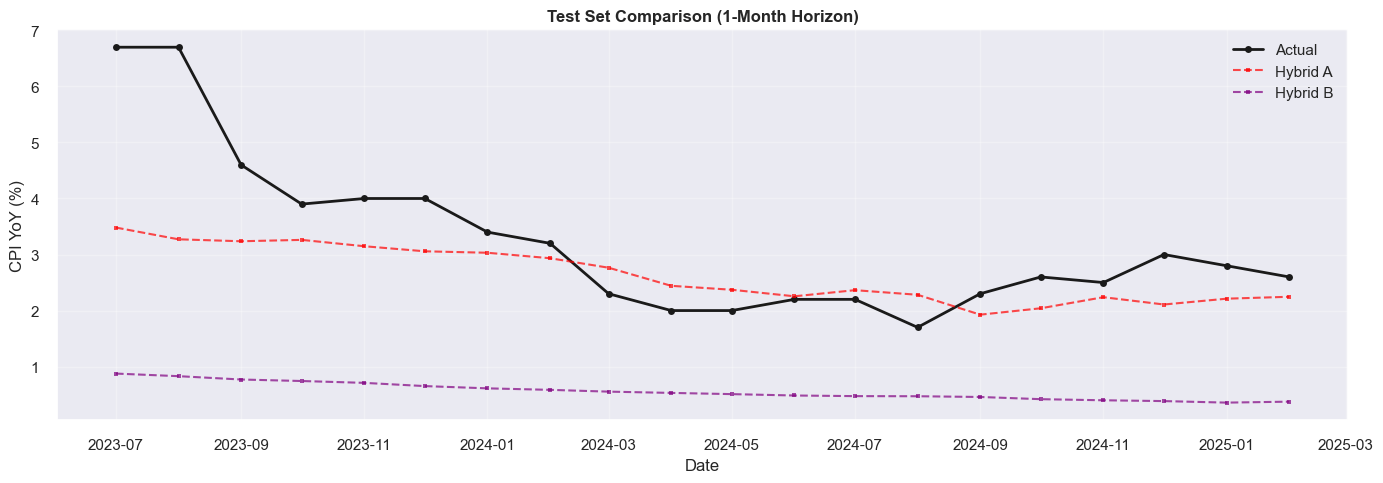

Plot 1: Time-series comparison


In [28]:
# Plot 1: Time-series comparison for 1-month horizon (t1)
fig, ax = plt.subplots(figsize=(14, 5))

test_dates_aligned = test_dates[lookback:]
ax.plot(test_dates_aligned, y_test[:, 0], 'ko-', label='Actual', linewidth=2, markersize=5)

colors = {'ARIMA': 'blue', 'RF': 'green', 'LSTM': 'orange', 'Hybrid A': 'red', 'Hybrid B': 'purple'}

for model_name, preds in predictions_dict.items():
    if preds is not None:
        ax.plot(test_dates_aligned, preds[:, 0], 's--', label=model_name, 
               color=colors[model_name], alpha=0.7, linewidth=1.5, markersize=3)

ax.set_title('Test Set Comparison (1-Month Horizon)', fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('CPI YoY (%)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Plot 1: Time-series comparison")

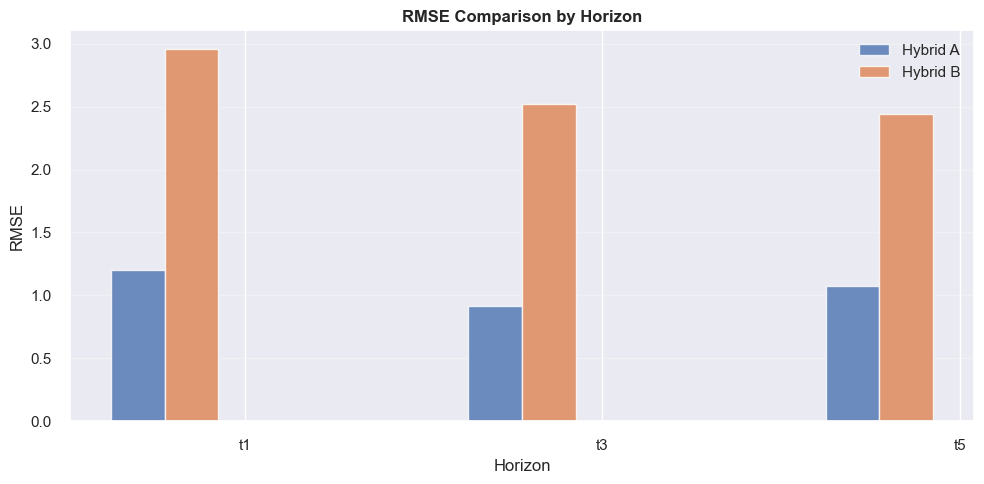

Plot 2: RMSE by horizon


In [29]:
# Plot 2: RMSE comparison across horizons
rmse_data = []

for model_name, preds in predictions_dict.items():
    if preds is None:
        continue
    for i, horizon in enumerate(['t1', 't3', 't5']):
        rmse = np.sqrt(mean_squared_error(y_test[:, i], preds[:, i]))
        rmse_data.append({'Model': model_name, 'Horizon': horizon, 'RMSE': rmse})

rmse_df = pd.DataFrame(rmse_data)

fig, ax = plt.subplots(figsize=(10, 5))
horizons = ['t1', 't3', 't5']
x = np.arange(len(horizons))
width = 0.15

models_plot = rmse_df['Model'].unique()
for i, model in enumerate(models_plot):
    model_data = rmse_df[rmse_df['Model'] == model].sort_values('Horizon')
    ax.bar(x + i * width, model_data['RMSE'], width, label=model, alpha=0.8)

ax.set_xlabel('Horizon')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison by Horizon', fontweight='bold', fontsize=12)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(horizons)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("Plot 2: RMSE by horizon")

## Summary

- **Best performing model**: Check RMSE column in comparison table above
- **Worst performing model**: Check RMSE column
- **Most balanced across horizons**: Check per-horizon RMSE columns

**Instructions to populate this table:**
1. Run notebook 03 (ARIMA) completely
2. Run notebook 04 (LSTM & RF) completely
3. Return to this notebook and run all cells
4. The comparison table will show all 5 models side-by-side